In [1]:
import numpy as np
import pandas as pd
import zipfile
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv('bank_transactions_data_2.csv')

In [3]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [4]:
df.shape

(2512, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [6]:
df.isnull().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [7]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [8]:
num_feature=[f for f in df if(df[f].dtype!='O')]

print('number of numerical featue {}'.format(len(num_feature)))

df[num_feature].head()

number of numerical featue 5


,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,70,81,1,5112.21
1,376.24,68,141,1,13758.91
2,126.29,19,56,1,1122.35
3,184.50,26,25,1,8569.06
4,13.45,26,198,1,7429.40


In [9]:
num_feature

['TransactionAmount',
 'CustomerAge',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

In [10]:
dis_feature=[f for f in num_feature if len(df[f].unique())<20 ]

df[dis_feature].head(50)

,LoginAttempts
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1


In [11]:
continue_feature=[f for f in num_feature if f not in dis_feature]
continue_feature

['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'AccountBalance']

In [12]:
df[continue_feature].head()

,TransactionAmount,CustomerAge,TransactionDuration,AccountBalance
0,14.09,70,81,5112.21
1,376.24,68,141,13758.91
2,126.29,19,56,1122.35
3,184.50,26,25,8569.06
4,13.45,26,198,7429.40


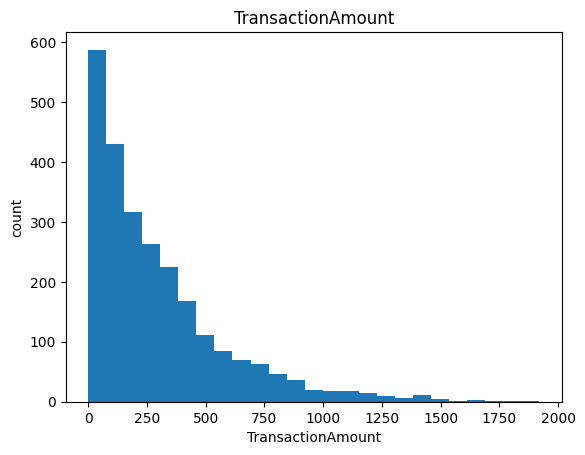

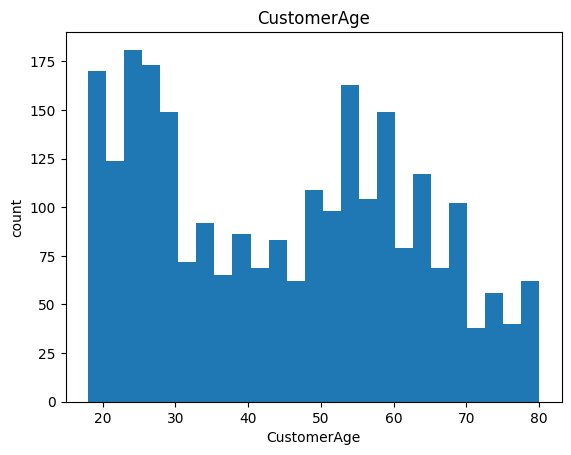

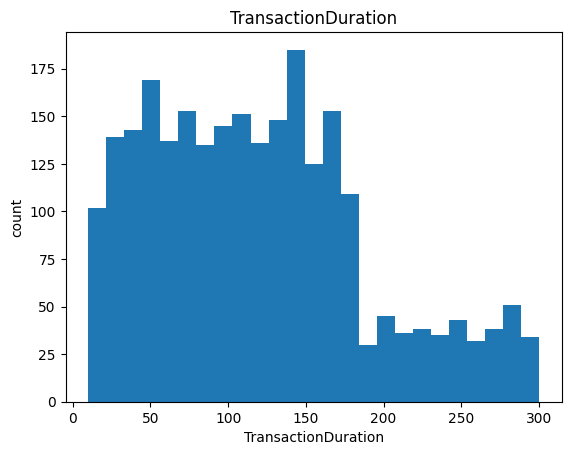

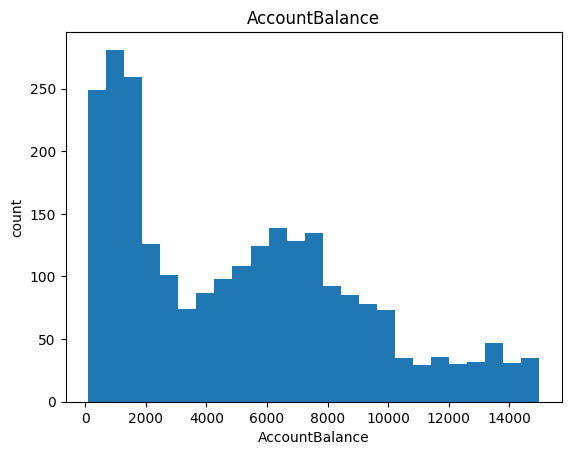

In [13]:
for f in continue_feature:
    data=df.copy()
    data[f].plot.hist(bins=25)
    plt.title(f)
    plt.xlabel(f)
    plt.ylabel('count')
    plt.show()

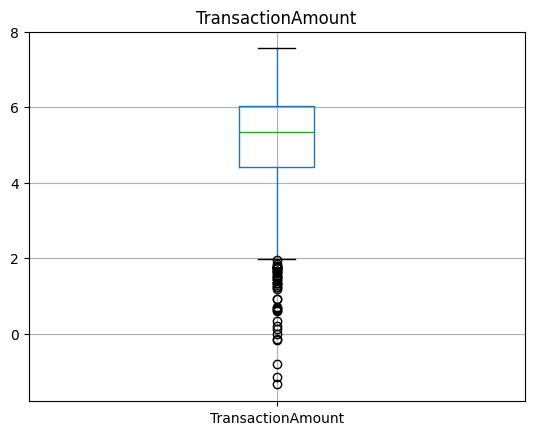

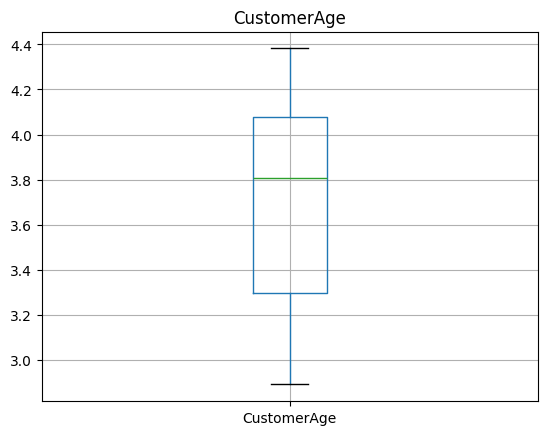

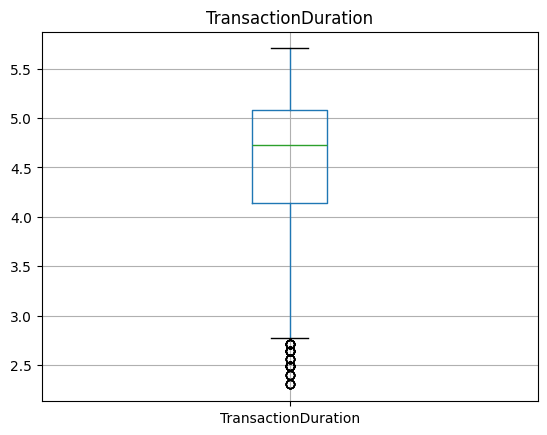

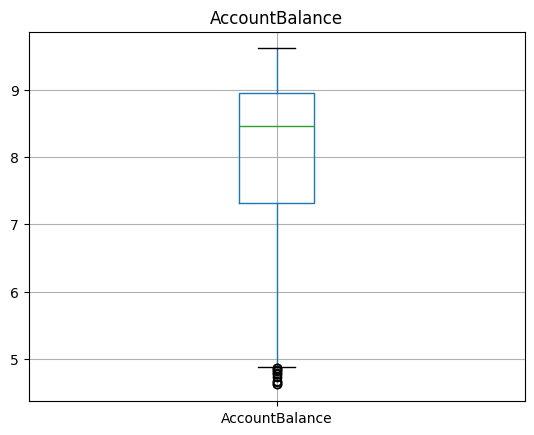

In [14]:
for f in continue_feature:
    data=df.copy()
    if 0 in data[f].unique():
     pass
    else:
       data[f]=np.log(data[f])
       data.boxplot(f)
       plt.title(f)
       plt.show()

In [15]:
cat_feature=[f for f in df if df[f].dtype=='O']
cat_feature

['TransactionID',
 'AccountID',
 'TransactionDate',
 'TransactionType',
 'Location',
 'DeviceID',
 'IP Address',
 'MerchantID',
 'Channel',
 'CustomerOccupation',
 'PreviousTransactionDate']

In [16]:
df[cat_feature].head()

,TransactionID,AccountID,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerOccupation,PreviousTransactionDate
0,TX000001,AC00128,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,Doctor,2024-11-04 08:08:08
1,TX000002,AC00455,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,Doctor,2024-11-04 08:09:35
2,TX000003,AC00019,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,Student,2024-11-04 08:07:04
3,TX000004,AC00070,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,Student,2024-11-04 08:09:06
4,TX000005,AC00411,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,Student,2024-11-04 08:06:39


In [17]:
for f in cat_feature:
    print('{} contain {} catogries'.format(f,len(data[f].unique())))

TransactionID contain 2512 catogries
AccountID contain 495 catogries
TransactionDate contain 2512 catogries
TransactionType contain 2 catogries
Location contain 43 catogries
DeviceID contain 681 catogries
IP Address contain 592 catogries
MerchantID contain 100 catogries
Channel contain 3 catogries
CustomerOccupation contain 4 catogries
PreviousTransactionDate contain 360 catogries


In [18]:
def vectorizer(df):
    vectorizer = TfidfVectorizer()
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = vectorizer.fit_transform(df[col]).toarray()
    return df

In [19]:
df = vectorizer(df)

In [20]:
X = df.drop('Location', axis = 1)
y = df['Location']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [22]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

feature_sel_model = SelectFromModel(Lasso(alpha=0.005, random_state=0)) 
feature_sel_model.fit(X_train, y_train)

SelectFromModel(estimator=Lasso(alpha=0.005, random_state=0))

In [23]:
feature_sel_model.get_support()

array([False, False,  True, False, False, False, False, False, False,
        True, False,  True, False, False, False])

In [24]:
selected_feat = X_train.columns[(feature_sel_model.get_support())]

# let's print some stats
print('total features: {}'.format((X_train.shape[1])))
print('selected features: {}'.format(len(selected_feat)))
print('features with coefficients shrank to zero: {}'.format(
    np.sum(feature_sel_model.estimator_.coef_ == 0)))

total features: 15
selected features: 3
features with coefficients shrank to zero: 11


In [25]:
regr = LinearRegression()

regr.fit(X_train, y_train)

print(regr.score(X_test, y_test))

-0.006145777288874887


In [26]:
selected_feat

Index(['TransactionAmount', 'CustomerAge', 'TransactionDuration'], dtype='object')

In [27]:
y_binary = (y > np.median(y)).astype(int)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42)

In [29]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [31]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 98.81%


In [32]:
X = df.drop('Location', axis=1)
X = X.iloc[:, :2]
y = df['Location']

In [33]:
svm = SVC(kernel="rbf", gamma=0.5, C=1.0)
svm.fit(X, y)

SVC(gamma=0.5)

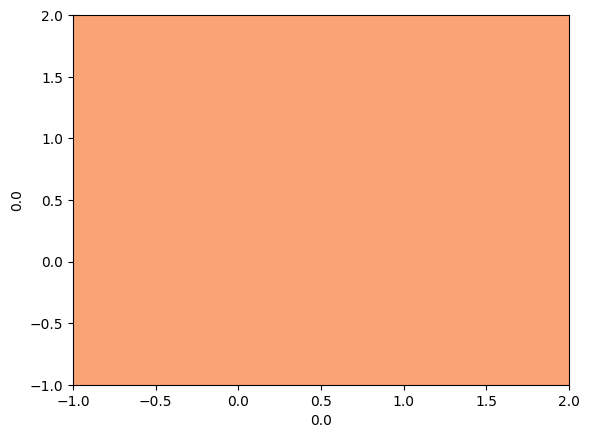

In [34]:
DecisionBoundaryDisplay.from_estimator(
    svm,
    X,
    response_method="predict",
    cmap=plt.cm.Spectral,
    alpha=0.8,
    xlabel=df.Location[0],
    ylabel=df.Location[1],
)

In [35]:
X = df.drop("Location", axis=1)
y = df['Location']

In [36]:
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [37]:
gnb = GaussianNB()

gnb.fit(X_train, y_train)

GaussianNB()

In [38]:
y_pred = gnb.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9827586206896551


In [39]:
X = df.drop('Location', axis=1)
df['target'] = df["Location"]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, df['target'], random_state=0)

In [41]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [42]:
y_pred = clf.predict(X_test)

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9585987261146497


In [44]:
df['Location'] = df['Location'].astype(str)

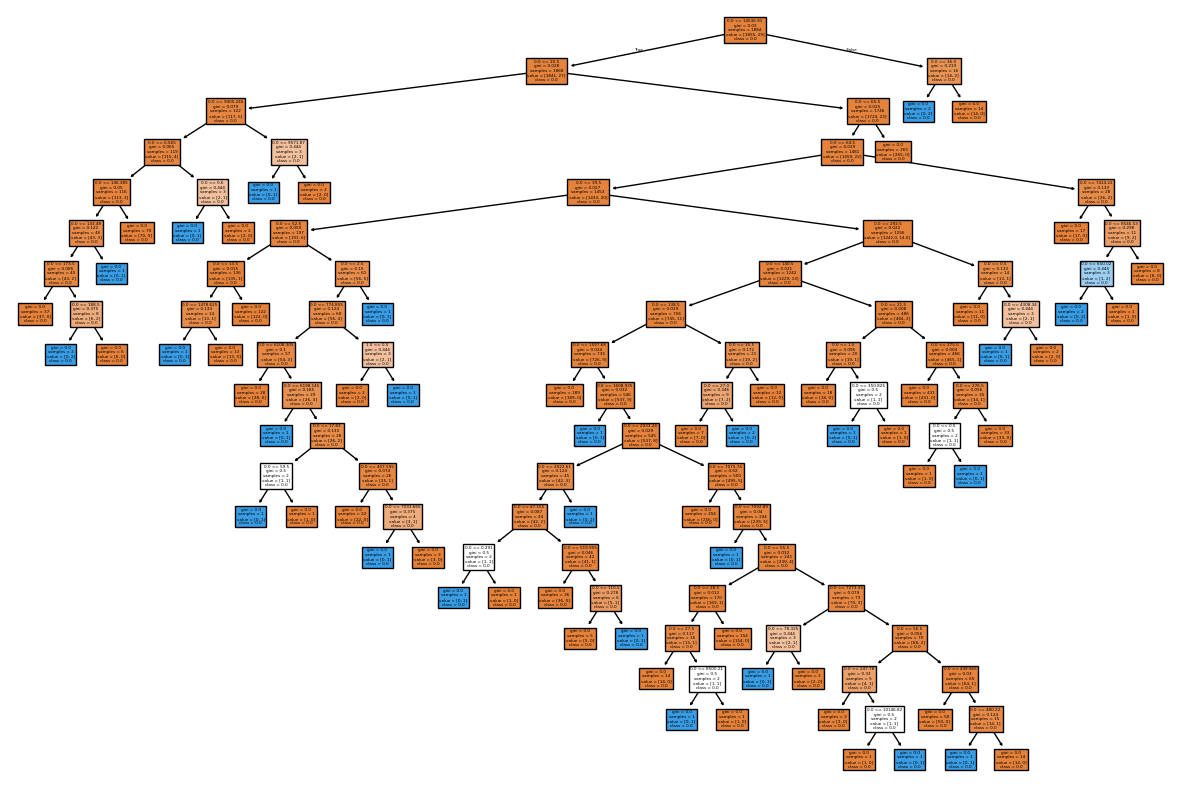

In [45]:
fig = plt.figure(figsize=(15,10))
_ = tree.plot_tree(clf,
                   feature_names=df.Location,
                   class_names=df.Location,
                   filled=True)

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
             X, y, test_size = 0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(X_train, y_train)

print(knn.score(X_test, y_test))

0.9880715705765407


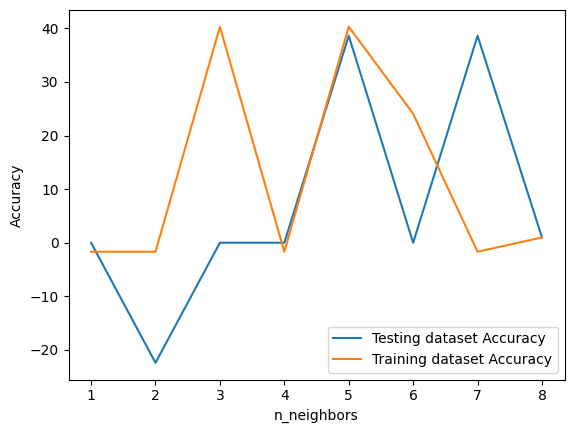

In [47]:
neighbors = np.arange(1, 9)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

for i, k in enumerate(neighbors):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

train_accuracy[i] = knn.score(X_train, y_train)
test_accuracy[i] = knn.score(X_test, y_test)

# Generate plot
plt.plot(neighbors, test_accuracy, label = 'Testing dataset Accuracy')
plt.plot(neighbors, train_accuracy, label = 'Training dataset Accuracy')

plt.legend()
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.show()

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

In [ ]:
ry_pred = rf_model.predict(X_test)  


In [40]:
accuracy = accuracy_score(y_test, ry_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.99


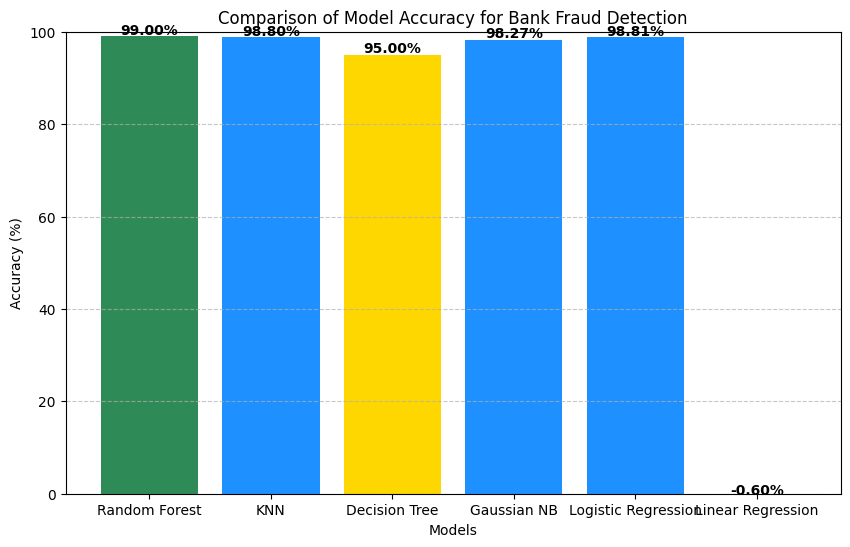

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


models = ["Random Forest", "KNN", "Decision Tree", "Gaussian NB", "Logistic Regression", "Linear Regression"]
accuracy = [99, 98.80, 95, 98.27, 98.81, -0.6]


colors = ['#2E8B57' if acc >= 99 else  
          '#1E90FF' if acc >= 98 else  
          '#FFD700' if acc >= 95 else  
          '#FF4500' for acc in accuracy]  


plt.figure(figsize=(10, 6))
plt.bar(models, accuracy, color=colors)


plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Model Accuracy for Bank Fraud Detection")
plt.ylim(0, 100)  
plt.grid(axis='y', linestyle='--', alpha=0.7)


for i, acc in enumerate(accuracy):
    plt.text(i, acc + 0.5, f"{acc:.2f}%", ha='center', fontsize=10, fontweight='bold')


plt.show()
